Take results and plot them over the original image

### Imports

In [3]:
import numpy as np
import cv2

import warnings
from dotenv import load_dotenv
from google import genai
from google.genai import types
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

import torch.nn as nn
import torch
import torch.nn.functional as F
from typing import List, Dict, Any, Optional, Union, Tuple
import shutil
from itertools import combinations
from dataclasses import dataclass, asdict
import concurrent
import os, json, math, re
from pathlib import Path
import pandas as pd
import jinko_helpers as jinko
import easyocr 
import requests

try:
    client = genai.Client(api_key=os.environ.get("GOOGLE_API_KEY"))
except ImportError:
    warnings.warn("Google GenAI client not installed. LLM functionality will be disabled.", ImportWarning)
    # Define Mock classes/client here for file integrity

load_dotenv()

True

### Process image

In [4]:
@dataclass
class TextDetection:
    text: str
    conf: float
    box: List[Tuple[int, int]]  # 4 points [(x1,y1),...]
    center: Tuple[float, float]

@dataclass
class TickLabel:
    value: float
    text: str
    pixel: Tuple[float, float]
    axis: str  # "x" or "y" or "unknown"
    box: Optional[List[Tuple[int, int]]]  # optional box

@dataclass
class PlotRegion:
    bbox: Tuple[int, int, int, int]  # x, y, w, h
    ticks: List[TickLabel]

In [5]:
def _to_num_tokens(txt: str) -> List[str]:
    """Extract numeric-like tokens. Handles integers, floats, sci-notation, and simple ranges."""
    t = txt.replace("–", "-").replace("—", "-")
    import re
    return re.findall(r"-?\d+(?:[\.,]\d+)?(?:e[+-]?\d+)?", t, flags=re.I)

def _center_of_box(box: List[Tuple[int, int]]) -> Tuple[float, float]:
    xs = [p[0] for p in box]
    ys = [p[1] for p in box]
    return (float(sum(xs)) / 4.0, float(sum(ys)) / 4.0)

In [6]:
def run_easyocr(img_bgr: np.ndarray, lang: List[str], enhance: bool = True, allowlist: str | None = None, scale_up: float = 1.5) -> List[TextDetection]:
    """Run EasyOCR and return structured detections.

    Optional:
      - enhance: apply CLAHE
      - allowlist: restrict characters (e.g., digits for tick OCR)
      - scale_up: resize before OCR to help tiny text
    """
    proc = img_bgr.copy()
    if enhance:
        gray = cv2.cvtColor(proc, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        eq = clahe.apply(gray)
        proc = cv2.cvtColor(eq, cv2.COLOR_GRAY2BGR)
    if scale_up and scale_up != 1.0:
        proc = cv2.resize(proc, None, fx=scale_up, fy=scale_up, interpolation=cv2.INTER_CUBIC)

    reader = easyocr.Reader(lang, gpu=True)  # set gpu=False if needed
    results = reader.readtext(proc[:, :, ::-1], allowlist=allowlist)  # expects RGB

    out: List[TextDetection] = []
    for box, text, conf in results:  # box is 4 points
        try:
            text_clean = str(text).strip()
            if not text_clean:
                continue
            # Reverse the scale if we resized
            poly = []
            for (x, y) in box:
                if scale_up and scale_up != 1.0:
                    x = int(round(x / scale_up))
                    y = int(round(y / scale_up))
                poly.append((int(x), int(y)))
            out.append(
                TextDetection(
                    text=text_clean,
                    conf=float(conf),
                    box=poly,
                    center=_center_of_box(poly),
                )
            )
        except Exception:
            continue
    return out


In [ ]:
def _digits_margin_pass(
    img_bgr: np.ndarray,
    lang: List[str],
    conf_min: float = 0.2,
    scale_up: float = 3.0,
    band_frac: float = 0.15,
    x_axis_y: int | None = None,
    y_axis_x: int | None = None,
) -> List[TickLabel]:
    """
    OCR for numeric ticks around axes.

    - For the y-axis: crop a vertical strip around y_axis_x and run EasyOCR 3 times:
      0°, +90° (clockwise), and -90° (counter-clockwise). Map coords back to full image.
    - For the x-axis: crop a horizontal strip around x_axis_y (as before).
    - If an axis anchor is missing, fall back to legacy left/bottom margins.

    Returns a list[TickLabel].
    """
    H, W = img_bgr.shape[:2]
    ticks: List[TickLabel] = []

    # ---------- helpers ----------
    def _is_good_num(td) -> Optional[float]:
        if td.conf < conf_min:
            return None
        nums = _to_num_tokens(td.text)
        if not nums:
            return None
        try:
            return float(nums[0].replace(",", "."))
        except Exception:
            return None

    def _dedup_ticks(items: List[TickLabel], px_tol: int = 8, val_tol: float = 1e-6) -> List[TickLabel]:
        out: List[TickLabel] = []
        for t in items:
            x, y = t.pixel
            keep = True
            for u in out:
                ux, uy = u.pixel
                if abs(t.value - u.value) <= val_tol and (abs(x-ux) + abs(y-uy) <= px_tol):
                    keep = False
                    break
            if keep:
                out.append(t)
        return out

    # Map rotated ROI centers back to the original crop (and then to full image).
    def _map_box_from_rot(poly_rot: List[Tuple[int,int]], rot_code: int, orig_h: int, orig_w: int) -> List[Tuple[int,int]]:
        mapped = []
        for (u, v) in poly_rot:
            if rot_code == cv2.ROTATE_90_CLOCKWISE:
                # inverse of (u = h-1 - y, v = x)  ->  (x = v, y = h-1 - u)
                x = v
                y = (orig_h - 1) - u
            elif rot_code == cv2.ROTATE_90_COUNTERCLOCKWISE:
                # inverse of (u = y, v = w-1 - x)  ->  (x = w-1 - v, y = u)
                x = (orig_w - 1) - v
                y = u
            else:
                x, y = u, v
            mapped.append((int(x), int(y)))
        return mapped
    
    def _map_center_from_rot(center, rot_code, orig_h, orig_w):
        x_rot, y_rot = center  # EasyOCR centers are (x, y)
        if rot_code == cv2.ROTATE_90_CLOCKWISE:
            # same mapping as _map_box_from_rot for CLOCKWISE
            x = y_rot
            y = (orig_h - 1) - x_rot
        elif rot_code == cv2.ROTATE_90_COUNTERCLOCKWISE:
            # same mapping as _map_box_from_rot for COUNTERCLOCKWISE
            x = (orig_w - 1) - y_rot
            y = x_rot
        else:
            x, y = x_rot, y_rot
        return float(x), float(y)

    def _run_ocr_on_roi_with_rotations(roi_bgr: np.ndarray, axis: str, x0_off: int, y0_off: int) -> List[TickLabel]:

        h0, w0 = roi_bgr.shape[:2]

        def _ocr0():
            dets = run_easyocr(roi_bgr, lang, enhance=True,
                            allowlist="0123456789.-", scale_up=scale_up)
            out = []
            for td in dets:
                val = _is_good_num(td)
                if val is None:
                    continue
                cx, cy = td.center
                box0 = [(px + x0_off, py + y0_off) for (px, py) in td.box]
                out.append(TickLabel(val, td.text,
                                    (cx + x0_off, cy + y0_off),
                                    axis=axis, box=box0))
            return out

        def _ocr_cw():
            roi_cw = cv2.rotate(roi_bgr, cv2.ROTATE_90_CLOCKWISE)
            dets = run_easyocr(roi_cw, lang, enhance=True,
                            allowlist="0123456789.-", scale_up=scale_up)
            out = []
            for td in dets:
                val = _is_good_num(td)
                if val is None:
                    continue
                u, v = td.center
                x_local, y_local = _map_center_from_rot((u, v),
                                                        cv2.ROTATE_90_CLOCKWISE,
                                                        h0, w0)
                box_local = _map_box_from_rot(td.box,
                                            cv2.ROTATE_90_CLOCKWISE,
                                            h0, w0)
                box_full = [(px + x0_off, py + y0_off)
                            for (px, py) in box_local]
                out.append(TickLabel(val, td.text,
                                    (x_local + x0_off,
                                    y_local + y0_off),
                                    axis=axis, box=box_full))
            return out

        def _ocr_ccw():
            roi_ccw = cv2.rotate(roi_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
            dets = run_easyocr(roi_ccw, lang, enhance=True,
                            allowlist="0123456789.-", scale_up=scale_up)
            out = []
            for td in dets:
                val = _is_good_num(td)
                if val is None:
                    continue
                u, v = td.center
                x_local, y_local = _map_center_from_rot((u, v),
                                                        cv2.ROTATE_90_COUNTERCLOCKWISE,
                                                        h0, w0)
                box_local = _map_box_from_rot(td.box,
                                            cv2.ROTATE_90_COUNTERCLOCKWISE,
                                            h0, w0)
                box_full = [(px + x0_off, py + y0_off)
                            for (px, py) in box_local]
                out.append(TickLabel(val, td.text,
                                    (x_local + x0_off,
                                    y_local + y0_off),
                                    axis=axis, box=box_full))
            return out

        with ThreadPoolExecutor(max_workers=3) as ex:
            f0  = ex.submit(_ocr0)
            f90 = ex.submit(_ocr_cw)
            f_90 = ex.submit(_ocr_ccw)

            out0  = f0.result()
            out90 = f90.result()
            out_90 = f_90.result()


        all_results = out0 + out90 + out_90
        return _dedup_ticks(all_results, px_tol=8, val_tol=1e-6)

    # ---------- Y-axis strip (vertical numbers) ----------
    if y_axis_x is not None:
        # Asymmetric band: more to the left (outside) than to the right (inside plot)
        band_w_left  = int(band_frac * W)            # outside the plot
        band_w_right = int(band_frac * W * 0.5)      # slightly into the plot
        x0 = max(0, y_axis_x - band_w_left)
        x1 = min(W, y_axis_x + band_w_right)
        y_roi = img_bgr[:, x0:x1]
        ticks.extend(_run_ocr_on_roi_with_rotations(y_roi, axis="y", x0_off=x0, y0_off=0))
    else:
        # Legacy left margin
        left_w = int(band_frac * W)
        x0, x1 = 0, left_w
        y_roi = img_bgr[:, x0:x1]
        ticks.extend(_run_ocr_on_roi_with_rotations(y_roi, axis="y", x0_off=x0, y0_off=0))

    # ---------- X-axis strip (horizontal numbers) ----------
    if x_axis_y is not None:
        # Asymmetric band: more below (outside) than above (into the plot)
        band_h_below = int(band_frac * H)
        band_h_above = int(band_frac * H * 0.5)
        y0 = max(0, x_axis_y - band_h_above)
        y1 = min(H, x_axis_y + band_h_below)
        x_roi = img_bgr[y0:y1, :]
        # One orientation is enough for x-axis (labels are horizontal), but keep consistent call:
        ticks.extend(_run_ocr_on_roi_with_rotations(x_roi, axis="x", x0_off=0, y0_off=y0))
    else:
        # Legacy bottom margin
        bot_h = int(band_frac * H)
        y0, y1 = H - bot_h, H
        x_roi = img_bgr[y0:y1, :]
        ticks.extend(_run_ocr_on_roi_with_rotations(x_roi, axis="x", x0_off=0, y0_off=y0))

    return ticks


In [8]:
def process_image(
    image_path: str,
    lang: List[str] | None = None,
    numeric_conf_min: float = 0.3,
    x_axis_y: int | None = None,
    y_axis_x: int | None = None,
) -> Dict[str, Any]:
    """
    Full pipeline for step 1 enhancement.

    - If margins_only=False: behaves like before (OCR globally or per plot).
    - If margins_only=True: only scan strips around the given x_axis_y and y_axis_x
      to extract numeric tick labels.

    Returns a JSON-serializable dict.
    """
    if lang is None:
        lang = ["en"]

    img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    H, W = img_bgr.shape[:2]

    plots_json: List[Dict[str, Any]] = []

    if x_axis_y is None or y_axis_x is None:
        raise ValueError("margins_only=True requires x_axis_y and y_axis_x")

    ticks = _digits_margin_pass(
        img_bgr, lang,
        conf_min=numeric_conf_min,
        x_axis_y=x_axis_y,
        y_axis_x=y_axis_x,
    )
    full_box = (0, 0, W, H)
    plots_json.append(
        asdict(
            PlotRegion(
                bbox=full_box,
                ticks=ticks,
            )
        )
    )

    out = {
        "image_path": image_path,
        "image_size": {"width": int(W), "height": int(H)},
        "plots": plots_json,
    }
    return out


### Extract the axis

In [9]:
class AxisCal:
    def __init__(self, a: float, b: float, axis: str, mode: str = "linear"):
        self.a, self.b, self.axis, self.mode = float(a), float(b), axis, mode

    def _f(self, v):
        v = np.asarray(v, float)
        if self.mode.startswith("log"):
            log_base = float(self.mode[3:])
            v = np.clip(v, 1e-12, None)
            return np.log(v) / np.log(float(log_base))
        return v

    def v2p(self, v):
        v = self._f(v)
        return self.a * v + self.b

    def p2v(self, p):
        p = np.asarray(p, float)
        fv = (p - self.b) / (self.a if self.a != 0 else 1e-12)
        if self.mode.startswith("log"):
            log_base = float(self.mode[3:])
            return np.power(float(log_base), fv)
        return fv


In [10]:
def _detect_axes(
    img: np.ndarray,
    h_angle_deg: float = 3.0,
    v_angle_deg: float = 3.0,
    canny_lo: int = 50,
    canny_hi: int = 140,
    min_line_frac: float = 0.1,
    max_gap_px: int = 12,
):
    """
    Detect x and y axes using spatially constrained Hough transforms.

    Returns:
      (x_axis_y, y_axis_x, x_axis_span, y_axis_span)
    """

    import cv2, math, numpy as np

    H, W = img.shape[:2]

    # --- Edge detection ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img.copy()
    gray = cv2.bilateralFilter(gray, 5, 20, 20)
    edges = cv2.Canny(gray, canny_lo, canny_hi)

    edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    )

    min_len = int(min(H, W) * min_line_frac)

    def parallel_support(x0, y0, x1, y1, band=2):
        n = int(max(abs(x1 - x0), abs(y1 - y0))) + 1
        xs = np.linspace(x0, x1, n).astype(int)
        ys = np.linspace(y0, y1, n).astype(int)

        cnt = 0
        for x, y in zip(xs, ys):
            if 0 <= x < W and 0 <= y < H:
                cnt += np.count_nonzero(
                    edges[
                        max(0, y - band):min(H, y + band + 1),
                        max(0, x - band):min(W, x + band + 1)
                    ]
                )
        return cnt / max(1, n)

    def perpendicular_density_vertical(x, y0, y1, band=6):
        tot = 0
        for y in range(y0, y1):
            if 0 <= y < H:
                tot += np.count_nonzero(
                    edges[y, max(0, x - band):min(W, x + band)]
                )
        return tot / max(1, (y1 - y0))

    def perpendicular_density_horizontal(y, x0, x1, band=6):
        tot = 0
        for x in range(x0, x1):
            if 0 <= x < W:
                tot += np.count_nonzero(
                    edges[max(0, y - band):min(H, y + band), x]
                )
        return tot / max(1, (x1 - x0))

    def local_noise(x0, y0, x1, y1, pad=8):
        xa = max(0, min(x0, x1) - pad)
        xb = min(W, max(x0, x1) + pad)
        ya = max(0, min(y0, y1) - pad)
        yb = min(H, max(y0, y1) + pad)
        area = (xb - xa) * (yb - ya)
        if area <= 0:
            return 1.0
        return np.count_nonzero(edges[ya:yb, xa:xb]) / area

    # -------------------------------------------------
    # 1. Y-axis (left ROI only)
    # -------------------------------------------------
    left_limit = int(0.40 * W)
    edges_left = edges.copy()
    edges_left[:, left_limit:] = 0

    v_lines = cv2.HoughLinesP(
        edges_left,
        rho=1,
        theta=np.pi / 180,
        threshold=40,
        minLineLength=min_len,
        maxLineGap=max_gap_px,
    )

    y_axis_x = None
    y_axis_span = None
    best_v_score = 0.0

    if v_lines is not None:
        v_eps = math.tan(math.radians(v_angle_deg))

        for x0, y0, x1, y1 in v_lines.reshape(-1, 4):
            dy = abs(y1 - y0)
            dx = abs(x1 - x0)
            if dy == 0 or dx / dy > v_eps:
                continue

            length = math.hypot(x1 - x0, y1 - y0)

            ps = parallel_support(x0, y0, x1, y1)
            pd = perpendicular_density_vertical(
                int(round((x0 + x1) / 2)), min(y0, y1), max(y0, y1)
            )
            noise = local_noise(x0, y0, x1, y1)

            score = length * ps / ((1.0 + pd) * (1.0 + noise))

            if score > best_v_score:
                best_v_score = score
                y_axis_x = int(round((x0 + x1) / 2))
                y_axis_span = (min(y0, y1), max(y0, y1))

    # -------------------------------------------------
    # 2. X-axis (bottom ROI only)
    # -------------------------------------------------
    bottom_limit = int(0.60 * H)
    edges_bottom = edges.copy()
    edges_bottom[:bottom_limit, :] = 0

    h_lines = cv2.HoughLinesP(
        edges_bottom,
        rho=1,
        theta=np.pi / 180,
        threshold=10,
        minLineLength=min_len,
        maxLineGap=max_gap_px,
    )

    x_axis_y = None
    x_axis_span = None
    best_h_score = 0.0

    if h_lines is not None:
        h_eps = math.tan(math.radians(h_angle_deg))

        for x0, y0, x1, y1 in h_lines.reshape(-1, 4):
            dx = abs(x1 - x0)
            dy = abs(y1 - y0)
            if dx == 0 or dy / dx > h_eps:
                continue

            length = math.hypot(x1 - x0, y1 - y0)

            ps = parallel_support(x0, y0, x1, y1)
            pd = perpendicular_density_horizontal(
                int(round((y0 + y1) / 2)), min(x0, x1), max(x0, x1)
            )
            noise = local_noise(x0, y0, x1, y1)

            score = length * ps / ((1.0 + pd) * (1.0 + noise))

            if score > best_h_score:
                best_h_score = score
                x_axis_y = int(round((y0 + y1) / 2))
                x_axis_span = (min(x0, x1), max(x0, x1))

    if y_axis_x is None:
        y_axis_x = int(0.10 * W)
        y_axis_span = (0, H)

    if x_axis_y is None:
        x_axis_y = int(0.90 * H)
        x_axis_span = (0, W)

    return x_axis_y, y_axis_x, x_axis_span, y_axis_span


In [11]:
def normalize_axis_breaks(
    ticks: List[float],
    breaks: Union[List[Any], List[List[Any]]],
) -> Dict[str, Any]:
    """
    Normalize axis breaks.

    Supported break formats:
      - breaks = [lo, hi]                      (single break)
      - breaks = [[lo, hi], [lo2, hi2], ...]   (multiple breaks)

    Endpoints may be str/int/float; they are converted to float.

    Rules:
    - A break is kept ONLY if there are at least 2 ticks strictly below `lo`
      AND at least 2 ticks strictly above `hi`.
    - If either side has <= 1 tick:
        - remove the break
        - remove the isolated tick(s) on that side
    - Ticks remain numeric only.
    """

    if not ticks:
        return {"ticks": [], "breaks": []}

    # Ensure numeric ticks
    ticks_f = [float(t) for t in ticks]
    ticks_f.sort()

    # Normalize breaks into a list of [lo, hi] pairs
    break_pairs: List[List[Any]] = []
    if not breaks:
        return {"ticks": ticks_f, "breaks": []}

    # Case A: single break like [10, 50]
    if isinstance(breaks, (list, tuple)) and len(breaks) == 2 and not isinstance(breaks[0], (list, tuple)):
        break_pairs = [list(breaks)]
    # Case B: list of breaks like [[10, 50], [60, 120]]
    elif isinstance(breaks, (list, tuple)):
        break_pairs = list(breaks)  # may still contain malformed entries; filtered below
    else:
        # Unsupported type
        return {"ticks": ticks_f, "breaks": []}

    kept_breaks: List[List[float]] = []

    for br in break_pairs:
        if not isinstance(br, (list, tuple)) or len(br) != 2:
            continue

        try:
            lo = float(br[0])
            hi = float(br[1])
        except (TypeError, ValueError):
            continue

        if lo >= hi:
            continue

        below = [t for t in ticks_f if t <= lo]
        above = [t for t in ticks_f if t >= hi]
        print("Break", br, "has", len(below), "ticks below and", len(above), "ticks above.")
        # Case 1: meaningful break → keep
        if len(below) >= 2 and len(above) >= 2:
            kept_breaks.append([lo, hi])
            continue

        # Case 2: trivial break → prune sparse side(s)
        if len(below) <= 1:
            ticks_f = above

        if len(above) <= 1:
            ticks_f = below

    return {
        "ticks": ticks_f,
        "breaks": kept_breaks,
    }
def normalize_axis_if_needed(axis: dict) -> dict:
    """
    Normalize axis breaks only if they exist.
    Axis is modified in-place and also returned.
    """

    if not axis or "ticks" not in axis:
        return axis

    breaks = axis.get("break")

    if breaks is None:
        return axis

    if isinstance(breaks, list) and len(breaks) == 0:
        axis["break"] = []
        return axis

    # Normalize
    norm = normalize_axis_breaks(axis["ticks"], breaks)

    axis["ticks"] = norm["ticks"]
    axis["break"] = norm["breaks"]
    return axis

### Get the calibration

In [12]:
def _vandermonde(x, deg):
    # Columns in np.polyval order: x^deg ... x^0
    return np.vander(x, N=deg+1, increasing=False)

def _huber_weights(residuals, delta):
    r = np.abs(residuals)
    w = np.ones_like(r, dtype=float)
    mask = r > delta
    w[mask] = delta / (r[mask] + 1e-12)
    return w

def _ols_polyfit_on_set(x, y, deg):
    V = _vandermonde(x, deg)
    beta, *_ = np.linalg.lstsq(V, y, rcond=None)
    return beta  # np.polyval order

def _irls_huber_on_set(x, y, deg, beta0=None, max_iters=10, delta=None, tol=1e-6):
    """
    IRLS with Huber loss, *only* on the provided (x,y) set.
    Returns beta in np.polyval order (highest degree first).
    """
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    if beta0 is None:
        beta = _ols_polyfit_on_set(x, y, deg)
    else:
        beta = beta0.copy()

    if delta is None:
        span = max(1.0, float(np.max(y) - np.min(y)))
        delta = 0.03 * span  # ~3% of span

    for _ in range(max_iters):
        yhat = np.polyval(beta, x)
        r = y - yhat
        w = _huber_weights(r, delta)

        # Weighted least squares on this set
        V = _vandermonde(x, deg)
        Wsqrt = np.sqrt(np.clip(w, 1e-12, None))
        VW = V * Wsqrt[:, None]
        yW = y * Wsqrt
        beta_new, *_ = np.linalg.lstsq(VW, yW, rcond=None)

        if np.linalg.norm(beta_new - beta) <= tol * (1.0 + np.linalg.norm(beta)):
            beta = beta_new
            break
        beta = beta_new
    return beta

In [ ]:
def majority_polyfit(
    x,
    y,
    deg=1,
    n_trials=200,
    residual_tol=5.0,
    alpha=0.5,
    lambda_inlier=1.0,
    gamma_span=0.01,          # NEW: span reward
    random_state=None,
):
    """
    Robust polynomial fit with controlled exploration + axis-aware scoring.

    Additions vs original:
      - Huber loss instead of MSE
      - Score evaluated on the SAME set used for fitting
      - Span reward to avoid degenerate local fits
      - Leave-one-out rescue for single catastrophic outliers
    """
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    N = len(x)
    if N <= deg + 1:
        return np.polyfit(x, y, deg)

    s_min = max(2, deg + 1)
    s_max = N

    best_score = -np.inf
    best_beta = None
    best_set = None

    # -------------------------
    # Robust loss
    # -------------------------
    def huber_mean(resid, delta):
        a = np.abs(resid)
        quad = a <= delta
        out = np.empty_like(a, dtype=float)
        out[quad] = 0.5 * (a[quad] ** 2)
        out[~quad] = delta * (a[~quad] - 0.5 * delta)
        return float(out.mean())

    def score_on(beta, xs, ys):
        yhat = np.polyval(beta, xs)
        resid = ys - yhat
        loss = huber_mean(resid, residual_tol)
        n_used = len(xs)
        span = float(xs.max() - xs.min()) if n_used >= 2 else 0.0
        score = lambda_inlier * n_used - alpha * loss + gamma_span * span
        return score, loss, n_used, resid

    # --------------------
    # Case A: N <= 10 (exhaustive)
    # --------------------
    if N <= 10:
        for s in range(s_min, s_max + 1):
            for subset in combinations(range(N), s):
                subset = np.array(subset, int)
                xs, ys = x[subset], y[subset]

                beta0 = _ols_polyfit_on_set(xs, ys, deg)
                yhat = np.polyval(beta0, xs)
                resid = np.abs(ys - yhat)

                if np.any(resid > residual_tol):
                    continue

                score0, _, _, _ = score_on(beta0, xs, ys)
                if score0 > best_score:
                    best_score = score0
                    best_beta = beta0
                    best_set = subset

                beta1 = _irls_huber_on_set(xs, ys, deg, beta0=beta0, max_iters=10)
                score1, _, _, _ = score_on(beta1, xs, ys)
                if score1 > best_score:
                    best_score = score1
                    best_beta = beta1
                    best_set = subset

        if best_beta is None:
            return np.polyfit(x, y, deg)
        print("the best combination is : ", x[best_set], y[best_set], "with a score of ", best_score)
        return best_beta

    # --------------------
    # Case B: N > 10 (randomized)
    # --------------------
    sizes = np.arange(s_min, s_max + 1)
    weights = np.ones_like(sizes, float)
    weights[sizes <= 4] *= 3.0
    probs = weights / weights.sum()

    for _ in range(int(n_trials)):
        s = int(rng.choice(sizes, p=probs))
        subset_idx = np.sort(rng.choice(N, size=s, replace=False))
        xs, ys = x[subset_idx], y[subset_idx]

        beta0 = _ols_polyfit_on_set(xs, ys, deg)
        yhat = np.polyval(beta0, xs)
        resid = np.abs(ys - yhat)

        if np.any(resid > residual_tol):
            continue

        score0, _, _, _ = score_on(beta0, xs, ys)
        if score0 > best_score:
            best_score = score0
            best_beta = beta0
            best_set = subset_idx

        # --- Expand ---
        yhat_all = np.polyval(beta0, x)
        resid_all = np.abs(y - yhat_all)
        expanded_idx = np.where(resid_all <= residual_tol)[0]

        if expanded_idx.size < s_min:
            continue

        xs2, ys2 = x[expanded_idx], y[expanded_idx]
        beta1 = _irls_huber_on_set(xs2, ys2, deg, beta0=beta0, max_iters=10)
        score1, loss1, n1, resid2 = score_on(beta1, xs2, ys2)

        # --- Leave-one-out rescue (ONLY if one dominates) ---
        if xs2.size >= s_min + 1:
            worst = np.argmax(np.abs(resid2))
            xs3 = np.delete(xs2, worst)
            ys3 = np.delete(ys2, worst)

            beta2 = _irls_huber_on_set(xs3, ys3, deg, beta0=beta1, max_iters=10)
            score2, _, _, _ = score_on(beta2, xs3, ys3)

            if score2 > score1:
                score1 = score2
                beta1 = beta2

        if score1 > best_score:
            best_score = score1
            best_beta = beta1
            best_set = expanded_idx

    if best_beta is None:
        return np.polyfit(x, y, deg)
    return best_beta


In [14]:
def _extract_crop(img: np.ndarray, box: Tuple[int,int,int,int], pad: int=2) -> Tuple[np.ndarray, Tuple[int,int]]:
    H,W = img.shape[:2]
    x0,y0,x1,y1 = box
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return img[y0:y1+1, x0:x1+1], (x0,y0)

def _ink_mask(gray: np.ndarray) -> np.ndarray:
    # robust binarization for small labels
    g = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV|cv2.THRESH_OTSU)[1]
    # light open to remove specks, keep strokes
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT,(2,2)))
    return th

def _projection_profile(mask: np.ndarray, axis: str) -> np.ndarray:
    # axis == 'x' → vertical projection (sum per column) for x-axis labels
    # axis == 'y' → horizontal projection (sum per row)   for y-axis labels
    if axis == 'x':
        prof = mask.sum(axis=0)
    else:
        prof = mask.sum(axis=1)
    # mild smoothing
    return cv2.blur(prof.astype(np.float32).reshape(-1,1), (3,1)).ravel()

from scipy.signal import find_peaks

def _find_valleys(profile, min_prom_frac=0.05, min_sep_px=2):
    if profile.size < 8:
        return []
    p = (profile - profile.min()) / max(1e-6, (profile.max() - profile.min()))
    ip = 1.0 - p
    peaks, _ = find_peaks(ip, prominence=min_prom_frac, distance=min_sep_px)
    return peaks.tolist()

def _intensity_centroid(mask: np.ndarray) -> Tuple[float,float]:
    M = cv2.moments(mask, binaryImage=True)
    if M['m00'] <= 1e-6:
        h,w = mask.shape[:2]
        return w*0.5, h*0.5
    cx = M['m10']/M['m00']; cy = M['m01']/M['m00']
    return cx, cy

def _is_all_digits_or_sign(s: str) -> bool:
    if not isinstance(s, str) or not s:
        return False
    return all(ch.isdigit() or ch in "+-., " for ch in s)

def _closest_in_llm(val: float, llm_vals: List[float], atol_abs: float, atol_rel: float) -> Optional[float]:
    if not llm_vals:
        return None
    for lv in llm_vals:
        atol = max(atol_abs, atol_rel*max(1.0, abs(lv)))
        if abs(val - lv) <= atol:
            return lv
    return None

In [15]:
def _tok_quad_or_box(t):
    B = t.get("bbox") or t.get("box") or t.get("rect")

    if B is None:
        return None

    # Handle polygon form: [(x1,y1), (x2,y2), (x3,y3), (x4,y4)]
    if isinstance(B, (list, tuple)) and len(B) == 4 and isinstance(B[0], (list, tuple)):
        xs = [p[0] for p in B]
        ys = [p[1] for p in B]
        x0, x1 = min(xs), max(xs)
        y0, y1 = min(ys), max(ys)
        return int(x0), int(y0), int(x1), int(y1)

    # Handle flat [x0, y0, x1, y1]
    if isinstance(B, (list, tuple)) and len(B) == 4:
        x0, y0, x1, y1 = map(float, B)
        x0, x1 = sorted([x0, x1])
        y0, y1 = sorted([y0, y1])
        return int(x0), int(y0), int(x1), int(y1)

    return None

In [16]:
def _split_merged_digits_with_llm(
    img: np.ndarray,
    token: Dict[str,Any],
    axis: str,
    llm_vals: List[float],
    atol_abs: float = 0.25,
    atol_rel: float = 0.02,
    oversize_ratio: float = 1.8,
    min_prom_frac: float = 0.05,
    min_sep_px: int = 2
) -> List[Dict[str,Any]]:
    """
    If token’s box is oversized (vs typical digit) or text looks run-on (e.g. '9101112'),
    split by projection valleys, then greedily fuse adjacent chunks so that
    concatenated text parses to a number present in llm_vals (within tolerance).
    Each kept chunk gets its intensity centroid and becomes a new tick token.

    Returns: list of refined tokens (could be [token] if no split needed).
    """
    box = _tok_quad_or_box(token)
    if box is None:
        # no box: nothing to split
        return [token]

    # Extract crop & ink
    crop, (ox,oy) = _extract_crop(img, box, pad=1)
    if crop.size == 0:
        return [token]
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    mask = _ink_mask(gray)

    h,w = mask.shape[:2]
    txt = str(token.get("text", ""))

    # Heuristics: should we attempt splitting?
    should_try = False
    if _is_all_digits_or_sign(txt) and len(txt.replace(" ","")) >= 3:
        # long run-on looking string
        should_try = True
    # oversized box check vs a “single-digit-ish” size proxy:
    # use height for x-axis (horizontal text), width for y-axis (rotated cases)
    if axis == 'x' and w >= oversize_ratio * max(6, h*0.35):
        should_try = True
    if axis == 'y' and h >= oversize_ratio * max(6, w*0.35):
        should_try = True

    if not should_try:
        return [token]

    # Projection
    prof = _projection_profile(mask, axis)
    cuts = _find_valleys(prof, min_prom_frac=min_prom_frac, min_sep_px=min_sep_px)

    if len(cuts) == 0:
        # No clear valleys → keep as is
        return [token]

    # Build primitive segments between cuts
    segs = []
    if axis == 'x':
        xs = [0] + cuts + [w-1]
        for i in range(len(xs)-1):
            sx, ex = xs[i], xs[i+1]
            if ex - sx < 2: 
                continue
            segs.append(((sx,0,ex,h-1), mask[:, sx:ex]))
    else:
        ys = [0] + cuts + [h-1]
        for i in range(len(ys)-1):
            sy, ey = ys[i], ys[i+1]
            if ey - sy < 2:
                continue
            segs.append(((0,sy,w-1,ey), mask[sy:ey, :]))

    if not segs:
        return [token]

    # OPTIONAL: mini-OCR per segment to get digit strings (but we can also just concatenate raw)
    # Here we stick to concatenating original token.text by segment order using binary bounds.
    # Greedy L→R (or T→B) concatenation checked against LLM ticks
    refined: List[Dict[str,Any]] = []
    i = 0
    while i < len(segs):
        # Try growing window segs[i:j]
        accepted_j = None
        accepted_val = None
        accepted_centroid = None
        accepted_box_local = None

        for j in range(i+1, len(segs)+1):
            # Combine boxes i..j-1
            if axis == 'x':
                x0 = segs[i][0][0]; x1 = segs[j-1][0][2]
                y0 = 0; y1 = h-1
                submask = mask[:, x0:x1]
            else:
                y0 = segs[i][0][1]; y1 = segs[j-1][0][3]
                x0 = 0; x1 = w-1
                submask = mask[y0:y1, :]

            # Estimate centroid inside this combined region
            cx_local, cy_local = _intensity_centroid(submask)

            # We need a candidate numeric value; strategy:
            #  - If token.text is numeric-like, slice by proportional ranges (fallback),
            #  - Otherwise, rely on LLM-only geometry and skip numeric parse (we can’t validate).
            # Simpler: try to OCR submask? (you said “don’t code OCR here”), so we parse from token.text if plausible:
            val_candidate = None
            if _is_all_digits_or_sign(txt):
                # Map segment coverage to substring indices by width/height proportion
                if axis == 'x':
                    frac0, frac1 = x0/float(w), x1/float(w)
                else:
                    frac0, frac1 = y0/float(h), y1/float(h)
                s = txt.replace(" ", "")
                a = max(0, int(round(frac0 * len(s))))
                b = min(len(s), int(round(frac1 * len(s))))
                subs = s[a:b]
                # normalize separators
                subs = subs.replace(",", ".")
                try:
                    # common multi-digit formation; allow “-”, “.” once
                    if subs and (subs.strip("-").replace(".","",1).isdigit()):
                        val_candidate = float(subs)
                except Exception:
                    val_candidate = None

            # If we got a numeric candidate, test against LLM ticks
            if val_candidate is not None:
                match = _closest_in_llm(val_candidate, llm_vals, atol_abs, atol_rel)
                if match is not None:
                    accepted_j = j
                    accepted_val = match
                    if axis == 'x':
                        # centroid in global image coords
                        gx = ox + x0 + cx_local
                        gy = oy + cy_local
                    else:
                        gx = ox + cx_local
                        gy = oy + y0 + cy_local
                    accepted_centroid = (float(gx), float(gy))
                    if axis == 'x':
                        accepted_box_local = (ox + x0, oy + 0, ox + x1, oy + h-1)
                    else:
                        accepted_box_local = (ox + 0, oy + y0, ox + w-1, oy + y1)
            # keep trying to extend (prefer longer valid merges like “10” over “1”)

        if accepted_j is None:
            # Nothing matched LLM ticks; advance by 1 (drop tiny noise)
            i += 1
        else:
            # Emit refined token
            new_t = dict(token)  # copy base fields
            new_t["value"] = float(accepted_val)
            new_t["text"] = str(accepted_val)
            new_t["pixel"] = accepted_centroid
            new_t["bbox"]  = accepted_box_local
            refined.append(new_t)
            i = accepted_j
    

    # If nothing accepted, keep original token as fallback
    return refined if refined else [token]


In [17]:
def _coerce_float_list(x) -> List[float]:
    out = []
    for v in (x or []):
        try: out.append(float(v))
        except Exception: pass
    return out

def _refine_axis_tokens_with_valleys(
    img: np.ndarray,
    tokens: List[Dict[str,Any]],
    axis: str,
    llm_vals: List[float],
    atol_abs: float,
    atol_rel: float
) -> List[Dict[str,Any]]:
    out: List[Dict[str,Any]] = []
    for t in tokens:
        out.extend(
            _split_merged_digits_with_llm(
                img, t, axis, llm_vals,
                atol_abs=atol_abs, atol_rel=atol_rel
            )
        )
    return out

In [18]:
class TickCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.fc1 = nn.Linear(64 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [19]:
def _snap_tick_to_axis(
    img: np.ndarray,
    token: dict,
    axis: str,
    x_axis_y: int,
    y_axis_x: int,
    search_frac: float = 0.02,
    dist_bias_weight: float = 0.3,
    d_flat: float = 6.0,
    d_scale: float = 3.0,
    dist_power: float = 2.0,
    model: nn.Module = None,
    device: torch.device = torch.device("cpu"),
    min_confidence: float = 0.5,   # <-- NEW
) -> dict | None:
    """
    Model-only tick snapping.
    Returns None if confidence is too low.
    """

    # ------------------------------------------------------------
    # Validate token
    # ------------------------------------------------------------
    p = token.get("pixel")
    if not (isinstance(p, (list, tuple)) and len(p) == 2):
        return None

    cx, cy = map(int, p)
    H, W = img.shape[:2]

    # ------------------------------------------------------------
    # Grayscale + normalize (MATCH TRAINING)
    # ------------------------------------------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # ------------------------------------------------------------
    # Distance bias
    # ------------------------------------------------------------
    def dist_bias(dist):
        if dist <= d_flat:
            return 1.0
        x = (dist - d_flat) / d_scale
        return 1.0 / (1.0 + x ** dist_power)

    def _extract_tick_crop(gray: np.ndarray, cx: int, cy: int, size: int = 32):
        H, W = gray.shape
        half = size // 2

        crop = np.ones((size, size), dtype=np.float32)

        x0, x1 = cx - half, cx + half
        y0, y1 = cy - half, cy + half

        sx0, sx1 = max(0, x0), min(W, x1)
        sy0, sy1 = max(0, y0), min(H, y1)

        dx0 = sx0 - x0
        dy0 = sy0 - y0

        crop[
            dy0 : dy0 + (sy1 - sy0),
            dx0 : dx0 + (sx1 - sx0),
        ] = gray[sy0:sy1, sx0:sx1]

        return crop

    @torch.no_grad()
    def _model_confidence(crop: np.ndarray):
        x = torch.tensor(crop, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        x = x.to(device)
        logits = model(x)
        return torch.softmax(logits, dim=1)[0, 1].item()

    # ============================================================
    # Y-axis snapping
    # ============================================================
    if axis == "y":
        axis_x = int(y_axis_x)
        win = max(1, int(H * search_frac))
        y0, y1 = max(0, cy - win), min(H - 1, cy + win)

        best_y = cy
        best_score = -1e9
        best_conf = 0.0

        for y in range(y0, y1 + 1):
            crop = _extract_tick_crop(gray, axis_x, y)
            conf = _model_confidence(crop)

            dist = abs(y - cy)
            score = conf + dist_bias_weight * dist_bias(dist)

            if score > best_score:
                best_score = score
                best_y = y
                best_conf = conf

        # ✅ Reject low-confidence token
        if best_conf < min_confidence:
            return None

        token["pixel"] = (float(axis_x), float(best_y))
        token["snap_confidence"] = float(best_conf)
        return token

    # ============================================================
    # X-axis snapping
    # ============================================================
    if axis == "x":
        axis_y = int(x_axis_y)
        win = max(1, int(W * search_frac))
        x0, x1 = max(0, cx - win), min(W - 1, cx + win)

        best_x = cx
        best_score = -1e9
        best_conf = 0.0

        for x in range(x0, x1 + 1):
            crop = _extract_tick_crop(gray, x, axis_y)
            conf = _model_confidence(crop)

            dist = abs(x - cx)
            score = conf + dist_bias_weight * dist_bias(dist)

            if score > best_score:
                best_score = score
                best_x = x
                best_conf = conf

        # ✅ Reject low-confidence token
        if best_conf < min_confidence:
            return None

        token["pixel"] = (float(best_x), float(axis_y))
        token["snap_confidence"] = float(best_conf)
        return token

    return None


In [20]:
_NUM_RE = re.compile(r"^[+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?$", re.I)

def _is_numeric_str(s: str) -> bool:
    s = str(s).strip().replace("–","-").replace("—","-")
    return bool(_NUM_RE.match(s))

def _to_fit_value(v: float, mode: str, base: float = 10.0) -> Optional[float]:
    """
    Convert display-domain value to fit-domain value.

    mode:
      - "linear"
      - "log"  (generic log-k, base provided)
    """
    try:
        v = float(v)
    except Exception:
        return None

    if mode == "linear":
        return v

    if mode.startswith("log"):
        if v <= 0 or base <= 0 or base == 1:
            return None
        return math.log(v, base)

    raise ValueError(f"Unknown axis mode: {mode}")

def _tok_text(t: Dict[str, Any]) -> str:
    if "text" in t and isinstance(t["text"], str):
        return t["text"]
    if "value" in t:
        return str(t["value"])
    return ""

def _tok_pixel_center(t: Dict[str, Any]) -> Optional[Tuple[float,float]]:
    p = t.get("pixel")
    if isinstance(p, (list, tuple)) and len(p) == 2:
        try: return float(p[0]), float(p[1])
        except Exception: return None
    B = t.get("bbox") or t.get("box") or t.get("rect") or t.get("quad")
    if isinstance(B, (list, tuple)) and len(B) == 4:
        x0,y0,x1,y1 = map(float, B)
        return (0.5*(x0+x1), 0.5*(y0+y1))
    return None

In [21]:
def _intersect_with_llm(
    tokens: List[Dict[str, Any]],
    llm_vals: List[float],                 # DISPLAY-domain ticks (authoritative)
    value_tol_abs: float,
    value_tol_rel: float,
    axis_span: Tuple[float, float] = None, # DISPLAY-domain span (v0,v1)
    pixel_span: Tuple[float, float] = None,# (px0,px1)
    axis: str = "x",
    pixel_tol: float = 0.1,               # fraction of image dimension
    breaking: bool = False,
    break_expand: float = 1.3,
    border_factor: float = 1.8,
    mode: str = "linear",                  # "linear" | "log2" | "log10" | "logK"
    log_base: float = 10.0,                # used when mode startswith("log") but no base in mode
    H: int = 500,
    W: int = 500,
):
    """
    LLM ∩ OCR gating.

    - Membership is checked ONLY in DISPLAY space (never transformed).
    - Geometry is checked in FIT space using crude LLM span -> pixel span mapping.
    - Supports logK via mode like "log2"/"log10"/"log" + log_base.
    - Border ticks get extra tolerance.
    - Robust to duplicates: for each tick value, keeps only the best residual token.
    - Optional break-aware three-model logic.
    """
    explanations: List[Dict[str, Any]] = []
    kept: List[Dict[str, Any]] = []

    # absolute pixel tolerance
    pixel_tol_px = pixel_tol * (W if axis == "x" else H)

    if not tokens or not llm_vals:
        return [], [{"selected": False, "reason": "No tokens or no LLM tick values"}]

    llm_vals_arr = np.asarray(llm_vals, float)
    vmin = float(np.min(llm_vals_arr))
    vmax = float(np.max(llm_vals_arr))

    # -----------------------------
    # Build crude mapping in FIT space
    # -----------------------------
    have_span = False
    scale = None
    px0 = px1 = None
    fv0 = fv1 = None

    if axis_span is not None and pixel_span is not None:
        v0, v1 = axis_span
        px0, px1 = pixel_span

        fv0 = _to_fit_value(v0, mode, log_base)
        fv1 = _to_fit_value(v1, mode, log_base)

        if (
            fv0 is not None and fv1 is not None
            and np.isfinite(fv0) and np.isfinite(fv1)
            and (fv1 != fv0)
            and px0 is not None and px1 is not None
        ):
            scale = (px1 - px0) / float(fv1 - fv0)
            have_span = True

    # -----------------------------
    # First pass: membership, then residual compute (if possible)
    # -----------------------------
    cand = []

    for t in tokens:
        txt = _tok_text(t)
        p = _tok_pixel_center(t)

        entry = {
            "token": t,
            "text": txt,
            "pixel": p,
            "value": None,
            "selected": False,
            "reason": "",
        }

        if not _is_numeric_str(txt):
            entry["reason"] = f"Rejected: non-numeric text '{txt}'"
            explanations.append(entry)
            continue

        try:
            v = float(txt)
        except Exception:
            entry["reason"] = f"Rejected: cannot parse '{txt}'"
            explanations.append(entry)
            continue

        entry["value"] = v

        # DISPLAY-space membership only
        atol = max(value_tol_abs, value_tol_rel * max(1.0, abs(v)))
        if not np.any(np.isclose(v, llm_vals_arr, rtol=0.0, atol=atol)):
            entry["reason"] = "Rejected: not in LLM ticks"
            explanations.append(entry)
            continue

        # If we cannot do geometry, accept by membership (but note: this can let garbage through)
        if (not have_span) or (p is None):
            entry["selected"] = True
            entry["reason"] = "Selected: numeric match; no usable span/pixel"
            cand.append(entry)  # keep as candidate; we will still dedupe by value
            continue

        # FIT-space value for geometry
        fv = _to_fit_value(v, mode, log_base)
        if fv is None or not np.isfinite(fv):
            entry["reason"] = "Rejected: invalid fit value for axis mode"
            explanations.append(entry)
            continue

        x_px, y_px = p
        px_actual = float(x_px if axis == "x" else y_px)

        # predicted pixel from crude mapping
        if axis == "x":
            px_pred = float(px0 + (fv - fv0) * scale)
        else:
            px_pred = float(px1 - (fv - fv0) * scale)

        if not np.isfinite(px_pred):
            entry["reason"] = "Rejected: non-finite predicted pixel"
            explanations.append(entry)
            continue

        entry["px_actual"] = px_actual
        entry["px_pred"] = px_pred
        entry["residual"] = abs(px_actual - px_pred)

        cand.append(entry)

    if not cand:
        return [], explanations

    # -----------------------------
    # If geometry exists: residual gate (border-aware)
    # else: keep best per value by snap_confidence / area heuristic
    # -----------------------------
    by_value_best = {}  # v -> best entry
    for entry in cand:
        v = entry["value"]

        # Border-aware tol if residual exists
        if "residual" in entry:
            tol = pixel_tol_px * (border_factor if (v == vmin or v == vmax) else 1.0)
            ok = (entry["residual"] <= tol)

            if not ok and not breaking:
                entry["selected"] = False
                entry["reason"] = f"Rejected: residual {entry['residual']:.1f} > {tol:.1f}"
                explanations.append(entry)
                continue

            # If breaking, we postpone decision to break block below
            if not breaking:
                entry["selected"] = True
                entry["reason"] = f"Selected: residual {entry['residual']:.1f} ≤ {tol:.1f}"
        else:
            # No residual path: mark selected but we will dedupe heavily
            entry["selected"] = True
            entry["reason"] = "Selected: membership only (no geometry)"

        # Deduplicate per tick value: keep the best representative
        prev = by_value_best.get(v)
        if prev is None:
            by_value_best[v] = entry
        else:
            # Prefer smaller residual if available; else prefer higher snap_confidence
            r_new = entry.get("residual", float("inf"))
            r_old = prev.get("residual", float("inf"))

            if r_new < r_old:
                by_value_best[v] = entry
            elif r_new == r_old:
                sc_new = float(entry["token"].get("snap_confidence", 0.0))
                sc_old = float(prev["token"].get("snap_confidence", 0.0))
                if sc_new > sc_old:
                    by_value_best[v] = entry

        explanations.append(entry)

    # If breaking logic requested and we have spans, apply it ONLY on the best-per-value set
    if breaking and have_span:
        # Re-run break-aware selection on best representatives only
        best_entries = list(by_value_best.values())
        kept = []

        axis_range_px = abs(px1 - px0)
        shift = 0.2 * axis_range_px
        comp_factor = 0.8
        scale_C = scale * comp_factor

        tol_A = pixel_tol_px * 1.5 * break_expand
        tol_B = pixel_tol_px * 1.5 * break_expand
        tol_C = pixel_tol_px * 2.0 * break_expand

        for entry in best_entries:
            v = entry["value"]
            p = entry["pixel"]
            if p is None:
                continue

            fv = _to_fit_value(v, mode, log_base)
            if fv is None or not np.isfinite(fv):
                continue

            x_px, y_px = p
            pa = float(x_px if axis == "x" else y_px)

            # Model A
            if axis == "x":
                pxA = float(px0 + (fv - fv0) * scale)
                pxB = float((px0 + shift) + (fv - fv0) * scale)
                pxC = float(px0 + (fv - fv0) * scale_C)
            else:
                pxA = float(px1 - (fv - fv0) * scale)
                pxB = float((px1 - shift) - (fv - fv0) * scale)
                pxC = float(px1 - (fv - fv0) * scale_C)

            rA = abs(pa - pxA)
            rB = abs(pa - pxB)
            rC = abs(pa - pxC)

            border_mul = border_factor if (v == vmin or v == vmax) else 1.0

            okA = rA <= (tol_A * border_mul)
            okB = rB <= (tol_B * border_mul)
            okC = rC <= (tol_C * border_mul)

            if okA or okB or okC:
                kept.append(entry["token"])

        return kept, explanations

    # Non-breaking: return best-per-value tokens (already residual-gated if possible)
    kept = [e["token"] for e in by_value_best.values() if e.get("selected")]
    return kept, explanations

In [22]:
def _fit_axis_from_ticks(
    tokens: List[Dict[str,Any]],
    want_axis: str,
    axis_line_px: float,
    mode: str,
    log_base: float = 10.0,
    image=None,
) -> Optional[AxisCal]:

    vals_fit = []
    pixs = []
    for t in tokens:
        txt = _tok_text(t)
        if not _is_numeric_str(txt):
            print("Text for token:", t, "is", txt)
            continue

        p = _tok_pixel_center(t)
        if p is None:
            print("Pixel for token:", t, "is bugged")
            continue

        v_disp = float(txt)
        v_fit = _to_fit_value(v_disp, mode, log_base)
        if v_fit is None:
            continue

        if want_axis == "x":
            vals_fit.append(v_fit)
            pixs.append(p[0])
        else:
            vals_fit.append(v_fit)
            pixs.append(p[1])

    if len(vals_fit) < 2:
        print("Less than 2 ticks for axis", vals_fit, len(tokens))
        return None

    vals_fit = np.asarray(vals_fit, float)
    pixs = np.asarray(pixs, float)
    
    a, b = majority_polyfit(vals_fit, pixs)

    if want_axis == "x" and a < 0:
        a = abs(a)
    if want_axis == "y" and a > 0:
        a = -abs(a)

    return AxisCal(float(a), float(b), want_axis, mode)
   

In [23]:
def get_calibration(
    image_path: str,
    out_dir: str = "out_interval",
    near_tol: int = 10,
    far_tol: int = 5,

    # LLM guidance
    llm_axis_info: Optional[Dict[str, Any]] = None,  # {"x_axis":{"type","range","ticks"}, "y_axis":{...}}
    llm_value_tol_abs: float = 1e-6,
    llm_value_tol_rel: float = 0.02,
    res: Optional[Dict[str, Any]] = None,
    tokens_all: Optional[List[Dict[str,Any]]] = None,
):

    os.makedirs(out_dir, exist_ok=True)
    crops_dir = os.path.join(out_dir, "crops"); os.makedirs(crops_dir, exist_ok=True)

    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(image_path)
    H, W = img.shape[:2]

    # 0) Detect axes (no bbox needed)
    x_axis_y, y_axis_x, x_axis_span, y_axis_span = _detect_axes(img)

    # 1) LLM axis info (type/range/ticks)
    xi = llm_axis_info.get("x_axis", {}) if llm_axis_info else {}
    yi = llm_axis_info.get("y_axis", {}) if llm_axis_info else {}
    x_mode = str(xi.get("type", "linear")).lower() if xi else "linear"
    y_mode = str(yi.get("type", "linear")).lower() if yi else "linear"
    x_break = xi.get("break", False)
    y_break = yi.get("break", False)
    if not x_mode.startswith("log"): x_mode = "linear"
    if not y_mode.startswith("log"): y_mode = "linear"
    x_llm_ticks = _coerce_float_list(xi.get("ticks"))
    y_llm_ticks = _coerce_float_list(yi.get("ticks"))
    x_limits_llm = tuple(xi.get("range", ())) if isinstance(xi.get("range", ()), (list,tuple)) else None
    y_limits_llm = tuple(yi.get("range", ())) if isinstance(yi.get("range", ()), (list,tuple)) else None

    tokens_all: List[Dict[str, Any]] = []
    for plot in res.get("plots", []):
        tokens_all.extend(plot.get("ticks", []))
        tokens_all.extend(plot.get("labels", []))

    if not x_limits_llm and x_llm_ticks:
        lo, hi = float(min(x_llm_ticks)), float(max(x_llm_ticks))
        pad = 0.05 * max(1.0, hi - lo)
        x_limits_llm = (lo - pad, hi + pad)
    if not y_limits_llm and y_llm_ticks:
        lo, hi = float(min(y_llm_ticks)), float(max(y_llm_ticks))
        pad = 0.05 * max(1.0, hi - lo)
        y_limits_llm = (lo - pad, hi + pad)

    # 3) Gather likely tick-label tokens near each axis    
    def gather_axis_with_explanation(
        tokens,
        axis,              # "x" or "y"
        axis_px,           # pixel coordinate of this axis (y-axis x-position, or x-axis y-position)
        other_axis_px,     # pixel coordinate of the other axis
        near_tol=10,       # allowed distance from target axis in %
        far_tol=5         # must be farther than this from the other axis in %
    ):
        """
        Geometry-based axis tick selection with detailed explanations.

        Returns:
            selected_tokens, explanations_list

        Explanation for each token:
            {
                "text": "...",
                "pixel": (x,y),
                "selected": True/False,
                "reason": "clear English justification"
            }
        """
        if axis  == "x":
            near_tol = near_tol * H/100
            far_tol = far_tol  * W/100
        if axis == "y":
            near_tol = near_tol * W/100
            far_tol = far_tol  * H/100

        selected = []
        explanations = []

        for t in tokens:
            txt = str(t.get("text"))
            p   = t.get("pixel")

            # --- 1. must have pixel ---
            if p is None:
                explanations.append({
                    "text": txt, "pixel": None,
                    "selected": False,
                    "reason": "Rejected: token has no pixel coordinate"
                })
                continue

            x, y = p

            # --- 2. must be numeric ---
            try:
                _ = float(txt)
            except:
                explanations.append({
                    "text": txt, "pixel": p,
                    "selected": False,
                    "reason": f"Rejected: text '{txt}' is not numeric"
                })
                continue

            # --- 3. compute axis distances ---
            if axis == "x":
                d_axis = abs(y - axis_px)       # y-distance from x-axis baseline
                d_other = abs(x - other_axis_px)
            else: # axis == "y"
                d_axis = abs(x - axis_px)       # x-distance from y-axis baseline
                d_other = abs(y - other_axis_px)

            near = d_axis <= near_tol
            far  = d_other > far_tol

            # --- 4. decision ---
            if near and far:
                explanations.append({
                    "text": txt, "pixel": p, "selected": True,
                    "reason": (
                        f"Selected: near {axis}-axis (dist={d_axis} ≤ {near_tol}) "
                        f"and far from other axis (dist={d_other} > {far_tol})"
                    )
                })
                selected.append(t)
            else:
                reason = []
                if not near:
                    reason.append(f"too far from {axis}-axis (dist={d_axis} > {near_tol})")
                if not far:
                    reason.append(f"too close to other axis (dist={d_other} ≤ {far_tol})")
                explanations.append({
                    "text": txt, "pixel": p, "selected": False,
                    "reason": "Rejected: " + "; ".join(reason)
                })

        return selected, explanations

    def gather_x(tokens, x_axis_y, y_axis_x, near_tol=near_tol, far_tol=far_tol):
        return gather_axis_with_explanation(tokens, "x", x_axis_y, y_axis_x, near_tol, far_tol)

    def gather_y(tokens, y_axis_x, x_axis_y, near_tol=near_tol, far_tol=far_tol):
        return gather_axis_with_explanation(tokens, "y", y_axis_x, x_axis_y, near_tol, far_tol)

    raw_x, expl_x = gather_x(tokens_all, x_axis_y, y_axis_x)
    raw_y, expl_y = gather_y(tokens_all, y_axis_x, x_axis_y)

    raw_x = _refine_axis_tokens_with_valleys(img, raw_x, "x", x_llm_ticks or [], llm_value_tol_abs, llm_value_tol_rel)
    raw_y = _refine_axis_tokens_with_valleys(img, raw_y, "y", y_llm_ticks or [], llm_value_tol_abs, llm_value_tol_rel)
    raw_x = [t for t in raw_x if t.get("axis") == "x"]
    raw_y = [t for t in raw_y if t.get("axis") == "y"]

    import torch

    device = "cuda" if torch.cuda.is_available() else "cpu"

    tick_model = TickCNN()
    tick_model.load_state_dict(torch.load("tick_model.pth", map_location=device))
    tick_model.to(device)
    tick_model.eval()

    # Snap OCR ticks to actual axis stubs (closeness + stub length)
    raw_x = [
        t for t in (
            _snap_tick_to_axis(img, tok, "x", x_axis_y, y_axis_x,
                            model=tick_model, device=device)
            for tok in raw_x
        )
        if t is not None
    ]

    raw_y = [
        t for t in (
            _snap_tick_to_axis(img, tok, "y", x_axis_y, y_axis_x,
                            model=tick_model, device=device)
            for tok in raw_y
        )
        if t is not None
    ]

    # 4) LLM ∩ OCR gating (for calibration only)
    if x_mode.startswith("log"):
        log_base_x = float(x_mode[3:])
    else:
        log_base_x = 10
    if y_mode.startswith("log"):
        log_base_y = float(y_mode[3:])
    else:
        log_base_y = 10
    if x_llm_ticks and x_limits_llm:
        raw_x, explain_x = _intersect_with_llm(
                                raw_x,
                                x_llm_ticks,
                                llm_value_tol_abs,
                                llm_value_tol_rel,
                                axis_span=x_limits_llm,
                                pixel_span=x_axis_span,
                                axis="x",
                                breaking=x_break,
                                H=H,
                                W=W,
                                mode=x_mode,
                                log_base=log_base_x
                            )
    if y_llm_ticks and y_limits_llm:
        raw_y, explain_y = _intersect_with_llm(
                                raw_y,
                                y_llm_ticks,
                                llm_value_tol_abs,
                                llm_value_tol_rel,
                                axis_span=y_limits_llm,
                                pixel_span=y_axis_span,
                                axis="y",
                                breaking=y_break,
                                H=H,
                                W=W,
                                mode=y_mode,
                                log_base=log_base_y
                            )
        
    # 5) Calibrate (ticks → AxisCal), then fallbacks if needed
    cal_y = _fit_axis_from_ticks(raw_y, 'y', x_axis_y, y_mode, log_base_y, image=image_path)
    cal_x = _fit_axis_from_ticks(raw_x, 'x', y_axis_x, x_mode, log_base_x, image=image_path)
    
    return cal_x, cal_y



In [24]:
def axis_properties_tool(ocr_results: Dict[str, Any], image_path: str, axis_info: dict, out_dir: str = "out_interval") -> dict:
    """
    1) Store AXIS_INFO (including rotation_deg for both axes).
    2) Build calibration exactly like your pipeline:
       - Pass llm_axis_info into get_calibration() to calibrate.
       - Use a minimal 'intervals' list containing only {"id":"scale"} so no crops are forced.
    Returns: {"ok": True, "axis_info":..., "calibration": {...}}
    """
    global last_axis_info, last_calibration, last_crops_obj
    last_axis_info = axis_info or {}
    
    y_axis = axis_info["y_axis"]
    x_axis = axis_info["x_axis"]
    x_axis = normalize_axis_if_needed(x_axis)
    y_axis = normalize_axis_if_needed(y_axis)

    cal_x, cal_y = get_calibration(
        image_path=image_path,
        out_dir=out_dir,
        llm_axis_info=axis_info,
        res=ocr_results
    )
    return cal_x, cal_y

### LLM utils

In [25]:
CALIBRATION_SYSTEM_PROMPT = """
You are an axis calibration specialist.

Your sole task is to infer accurate axis properties from the chart image.

You do NOT select pipelines.
You do NOT extract data points.
You do NOT reason about chart semantics beyond axis meaning.

### Your task:
- Identify X and Y axis properties
- Determine:
  - axis type (linear, logK with K being an integerer so 10, 2, 5, ...)
  - visible tick values
  - approximate numeric range
  - presence of breaks or discontinuities (if any)

### Axis breaks:
- If an axis has a break, describe breaks using a separate `breaks` field.
- Each break must specify the numeric values it separates.
    Example:
    {
    "ticks": [0, 10, 50, 100],
    "breaks": [[10, 50], [50, 100]]
    }
    
### Rules:
- Always call `axis_properties_tool`.
- Provide the most complete AXIS_INFO possible.
- Do NOT output commentary.
- Do NOT repeat calibration after it has been done.

"""

CALIBRATION_USER_PROMPT = """
Analyze the chart image and extract full axis calibration information.
Infer axis ticks, and numeric range as precisely as possible.
"""


In [26]:
def _get_mime_type(file_path: str) -> str:
    ext = os.path.splitext(file_path)[1].lower()
    return 'image/jpeg' if ext in ['.jpg', '.jpeg'] else 'image/png'

def create_function_declaration(tool_dict):
    return types.Tool(function_declarations=[types.FunctionDeclaration(name=tool_dict["name"], description=tool_dict["description"], parameters=types.Schema(**tool_dict["parameters"]))])

axis_properties_tool_def = {
    "name": "axis_properties_tool",
    "description":  "Store axis properties and produce calibrated AxisCal objects.",
    "parameters": {
        "type": "OBJECT",
        "properties": {
            "axis_info": {
                "type": "OBJECT",
                "properties": {
                    "x_axis": {"type": "OBJECT", "properties": {"type": {"type": "STRING"}, "ticks": {"type": "ARRAY", "items": {"type": "NUMBER"}}, "break": {"type": "ARRAY", "items": {"type": "NUMBER"}}}, "required": ["type", "ticks"]}, 
                    "y_axis": {"type": "OBJECT", "properties": {"type": {"type": "STRING"}, "ticks": {"type": "ARRAY", "items": {"type": "NUMBER"}}, "break": {"type": "ARRAY", "items": {"type": "NUMBER"}}}, "required": ["type", "ticks"]},
                },
                "required": ["x_axis", "y_axis"],
            }
        },
        "required": ["axis_info"]
    }
}


### Drawing utils

In [27]:
def draw_calibrated_axes_from_axis_info(ax, x_cal, y_cal, axis_info, W, H):
    """
    Draw calibrated axes ticks on an existing matplotlib axis.
    Assumes image coordinate system (origin top-left).
    """

    # X axis ticks
    x_ticks = axis_info["x_axis"].get("ticks", [])
    for v in x_ticks:
        px = x_cal.v2p(v)
        ax.plot([px, px], [H - 6, H], color="black", lw=1)
        ax.text(px, H - 8, f"{v:g}", ha="center", va="top", fontsize=8)

    # Y axis ticks
    y_ticks = axis_info["y_axis"].get("ticks", [])
    for v in y_ticks:
        py = y_cal.v2p(v)
        ax.plot([0, 6], [py, py], color="black", lw=1)
        ax.text(8, py, f"{v:g}", ha="left", va="center", fontsize=8)

from collections import defaultdict

def normalize_result_to_series(rows):
    """
    Convert flat list of rows into the structure expected
    by save_extracted_series_images().
    """
    grouped = defaultdict(list)

    for r in rows:
        sid = r["series_id"]
        grouped[sid].append({"x": r["x"], "y": r["y"]})

    series = []
    for i, (sid, pts) in enumerate(grouped.items()):
        series.append({
            "label": sid,
            "points": pts
        })

    return {"series": series}


def save_extracted_series_images(
    result: dict,
    image_path: str,
    x_cal,
    y_cal,
    axis_info,
    out_dir: str,
    prefix: str,
    dpi: int = 150,
):
    """
    Save per-series and combined overlays + CSVs.
    """
    if os.path.isdir(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    overlays_dir = os.path.join(out_dir, "overlays")
    csv_dir = os.path.join(out_dir, "csv")
    os.makedirs(overlays_dir, exist_ok=True)
    os.makedirs(csv_dir, exist_ok=True)

    series_list = result.get("series", [])
    if not series_list:
        print("⚠️ No series to plot.")
        return

    img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Failed to load image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    all_values_rows = []
    all_pixels_rows = []

    for i, s in enumerate(series_list):
        pts = s.get("points", [])
        if not pts:
            continue

        label = s.get("label", f"Series {i}")

        x_raw = np.array([float(p["x"]) for p in pts])
        y_raw = np.array([float(p["y"]) for p in pts])

        x_px = x_cal.v2p(x_raw)
        y_px = y_cal.v2p(y_raw)

        # ---- CSVs ----
        pd.DataFrame({"x": x_raw, "y": y_raw}).to_csv(
            os.path.join(csv_dir, f"{prefix}_series_{i}_values.csv"),
            index=False,
        )

        pd.DataFrame({"x_px": x_px, "y_px": y_px}).to_csv(
            os.path.join(csv_dir, f"{prefix}_series_{i}_pixels.csv"),
            index=False,
        )

        for xv, yv, xp, yp in zip(x_raw, y_raw, x_px, y_px):
            all_values_rows.append(
                {"series_id": i, "series_label": label, "x": xv, "y": yv}
            )
            all_pixels_rows.append(
                {"series_id": i, "series_label": label, "x_px": xp, "y_px": yp}
            )

        # ---- Overlay ----
        fig, ax = plt.subplots(figsize=(W / dpi, H / dpi), dpi=dpi)
        ax.imshow(img_rgb)
        ax.plot(x_px, y_px, "-o", lw=2)
        draw_calibrated_axes_from_axis_info(ax, x_cal, y_cal, axis_info, W, H)
        ax.set_title(label)
        ax.axis("off")

        fig.savefig(
            os.path.join(overlays_dir, f"{prefix}_series_{i}_overlay.png"),
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0,
        )
        plt.close(fig)

    pd.DataFrame(all_values_rows).to_csv(
        os.path.join(csv_dir, f"{prefix}_all_series_values.csv"),
        index=False,
    )

    pd.DataFrame(all_pixels_rows).to_csv(
        os.path.join(csv_dir, f"{prefix}_all_series_pixels.csv"),
        index=False,
    )

    fig, ax = plt.subplots(figsize=(W / dpi, H / dpi), dpi=dpi)
    ax.imshow(img_rgb)

    for i, s in enumerate(series_list):
        pts = s.get("points", [])
        if not pts:
            continue

        x_raw = np.array([float(p["x"]) for p in pts])
        y_raw = np.array([float(p["y"]) for p in pts])

        ax.plot(
            x_cal.v2p(x_raw),
            y_cal.v2p(y_raw),
            lw=2,
            label=s.get("label", f"{i}"),
        )

    draw_calibrated_axes_from_axis_info(ax, x_cal, y_cal, axis_info, W, H)
    ax.legend(fontsize=8)
    ax.axis("off")

    combined_path = os.path.join(overlays_dir, f"{prefix}_all_overlay.png")
    fig.savefig(combined_path, dpi=dpi, bbox_inches="tight", pad_inches=0)

    # ---- SHOW ----
    plt.show()
    plt.close(fig)

    print(f"✅ Saved overlays and CSVs to: {out_dir}")
    print(f"📷 Combined overlay: {combined_path}")


### Loading stuff

In [28]:
def fetch_images_from_source_sid(
    jinko,
    source_sid: str,
    token: str,
    graphql_url: str,
    out_dir: str = "downloaded_images",
):
    """
    Replicates your exact extraction loop,
    but returns:
        imgs (list of cv2 images),
        image_paths (list of saved paths)
    """

    os.makedirs(out_dir, exist_ok=True)

    # --------------------------------------------------------
    # 1️⃣ Get extracts
    # --------------------------------------------------------
    extracts = jinko.make_request(
        f"/app/v1/project-item/{source_sid}/content"
    ).json().get("extracts", [])

    if not extracts:
        raise ValueError(f"No extracts found for SOURCE_SID={source_sid}")

    # --------------------------------------------------------
    # 2️⃣ Prepare GraphQL
    # --------------------------------------------------------
    headers = {
        "Cookie": f"{token}",
        "Content-Type": "application/json",
    }

    query = """
    query ProjectItemAppPanel($id: ID!) {
      projectItem(id: $id) {
        id: sid
        content {
          ... on Assertion {
            id
            highlights {
              ... on RectangularHighlight {
                id
                picture
              }
            }
          }
        }
      }
    }
    """

    imgs = []
    image_paths = []

    # --------------------------------------------------------
    # 3️⃣ Exact same loop structure as yours
    # --------------------------------------------------------
    for x in extracts:
        response = requests.post(
            graphql_url,
            headers=headers,
            json={"query": query, "variables": {"id": x["sid"]}},
        )

        data = response.json()

        content = data["data"]["projectItem"]["content"]
        if not content:
            continue

        highlights = content.get("highlights", [])
        if not highlights:
            continue

        for i, h in enumerate(highlights, 1):
            img_url = h["picture"]

            img_resp = requests.get(img_url, headers=headers)
            if img_resp.status_code != 200:
                continue

            filename = os.path.join(out_dir, f"{x['sid']}_{i}.png")

            with open(filename, "wb") as f:
                f.write(img_resp.content)

            img = cv2.imread(filename, cv2.IMREAD_COLOR)
            if img is None:
                continue

            imgs.append(img)
            image_paths.append(filename)

    if not imgs:
        raise ValueError(
            f"No highlight images found for SOURCE_SID={source_sid}"
        )

    return imgs[0], image_paths[0]


### Whole thing

In [38]:
dataId = "dt-RL2E-LJqu"
SOURCE_SID = "so-CLsk-P6BF"
TOKEN = "jinko-session=s%3AZWFhM2MwOWUtNmE1NS00YmJhLTk4YWMtOWYxMTg5YmYwMzVj%3AQlG___CvPCKSGnGW61Zeujj7OuCY_uX1.KWlzkmagcOmXHqE%2BCABnuGRdGD7xcy2%2FnBscMWITsHc"

In [ ]:
def main(datasId, imageId, TOKEN, verbose=False):
    JINKO_API_KEY = os.getenv("JINKO_API_KEY")
    JINKO_PROJECT_ID = os.getenv("JINKO_PROJECT_ID")
    JINKO_BASE_URL = os.getenv("JINKO_BASE_URL")

    JINKO_URL = os.getenv("JINKO_BASE_URL")+"/_api"

    jinko.initialize(JINKO_PROJECT_ID, JINKO_API_KEY, JINKO_BASE_URL, JINKO_URL)
    core_id = jinko.get_core_item_id(shortId=datasId)
    result = jinko.make_request(f"/core/v2/data_table_manager/data_table/{core_id['id']}/snapshots/{core_id['snapshotId']}/export", method="POST").json()

    MODEL_NAME = "gemini-3-pro-preview"

    img, image_path = fetch_images_from_source_sid(
        jinko=jinko,
        source_sid=imageId,
        token=TOKEN,
        graphql_url=JINKO_URL,
    )

    image_part = types.Part.from_bytes(
        data=Path(image_path).read_bytes(),
        mime_type=_get_mime_type(image_path),
    )
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Failed to load image")

    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(image_path)

    x_axis_y, y_axis_x, _, _ = _detect_axes(img)

    ocr_results = {}

    def run_ocr_job(image_path: str, x_axis_y: int, y_axis_x: int):
        return process_image(
            image_path=image_path,
            x_axis_y=x_axis_y,
            y_axis_x=y_axis_x,
        )

    def run_llm_job(client, model_name, image_part):
        response = client.models.generate_content(
            model=model_name,
            contents=[image_part, CALIBRATION_USER_PROMPT],
            config=types.GenerateContentConfig(
                system_instruction=CALIBRATION_SYSTEM_PROMPT,
                tools=[create_function_declaration(axis_properties_tool_def)],
                    thinking_config=types.ThinkingConfig(thinking_level="low"),
            ),
        )

        for call in getattr(response, "function_calls", []) or []:
            if call.name == "axis_properties_tool":
                return dict(call.args["axis_info"])

        raise RuntimeError("LLM did not call axis_properties_tool")

    # ---- RUN BOTH IN PARALLEL (SAFE) ----
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
        f_ocr = ex.submit(run_ocr_job, image_path, x_axis_y, y_axis_x)
        f_llm = ex.submit(run_llm_job, client, MODEL_NAME, image_part)

        # futures propagate exceptions here (in MAIN thread)
        ocr_results = f_ocr.result(timeout=120)
        axis_info  = f_llm.result(timeout=120)

    cal_x, cal_y = axis_properties_tool(
        ocr_results=ocr_results,
        image_path=image_path,
        axis_info=axis_info,
    )

    if verbose:
        print("=== FINAL AXIS CALIBRATION ===")
        print(f"X axis → a={cal_x.a:.6g}, b={cal_x.b:.6g}, mode={cal_x.mode}")
        print(f"Y axis → a={cal_y.a:.6g}, b={cal_y.b:.6g}, mode={cal_y.mode}")

    # ---- sanity checks ----
    assert cal_x.a != 0, "Invalid X-axis calibration"
    assert cal_y.a != 0, "Invalid Y-axis calibration"

    if cal_x.mode.startswith("log"):
        assert cal_x.a > 0, "Log X-axis must increase left→right"

    if cal_y.mode.startswith("log"):
        assert cal_y.a < 0, "Log Y-axis must increase upward"

    normalized_result = normalize_result_to_series(result)

    save_extracted_series_images(
        result=normalized_result,
        image_path=image_path,
        x_cal=cal_x,
        y_cal=cal_y,
        axis_info=axis_info,
        out_dir="out_series",
        prefix="chart",
    )


Authentication successful
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
/nix/store/grakrqqk1brn0npdiq0szqp3dpxn4wls-python3-3.12.10-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


we have a grand total of  6  points to fit a degree  1  polynomial.
the best combination is :  [3.  1.  1.5 2.  2.5 3.5] [184. 597. 495. 392. 288.  81.] with a score of  5.9440476190476215
we have a grand total of  5  points to fit a degree  1  polynomial.
the best combination is :  [1.2 1.4 1.6 1.7 1.8] [190. 325. 461. 529. 597.] with a score of  4.990913793103451


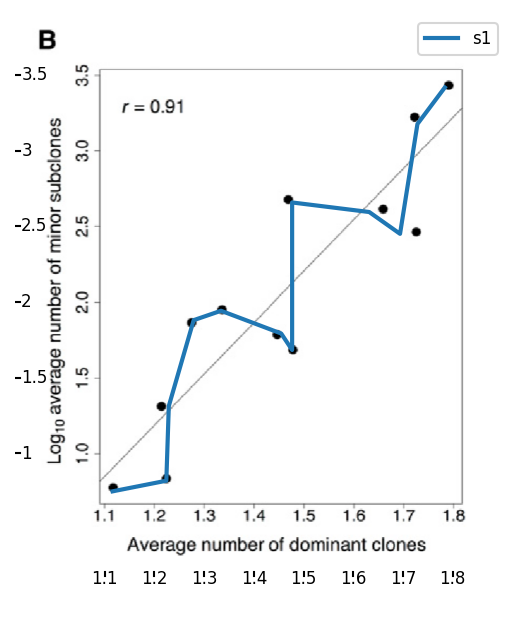

✅ Saved overlays and CSVs to: out_series
📷 Combined overlay: out_series/overlays/chart_all_overlay.png


In [40]:
main(dataId, SOURCE_SID, TOKEN)